# Predicting Customer Churn in a Telecommunications Company Using Machine Learning

**Final Project Notebook**  
**Dataset:** Telco Customer Churn  
**Prediction task:** Binary classification  
**Target variable:** `Churn`

**Prepared By:** Amit Chaulagain

This notebook is organized according to the final project guidelines:

1. Introduction & Background  
2. Data Preprocessing  
3. Data Visualization  
4. Data Analysis & Modeling  
5. Findings & Model Comparison  

The notebook also uses the main Python techniques practiced in class, including EDA, feature engineering, imputation, scaling, encoding, train/test split, cross-validation, pipelines, logistic regression, KNN, Naive Bayes, decision tree, bagging, random forest, gradient boosting, XGBoost/HistGradientBoosting, PCA, clustering, neural network modeling, and model comparison.

## 1. Introduction & Background

Customer churn is an important problem in the telecommunications industry because keeping existing customers is usually less expensive than finding new customers. If a company can predict which customers are likely to leave, it can take action early by offering better service, discounts, contract options, or customer support.

The dataset used in this project is the **Telco Customer Churn** dataset from Kaggle. It contains customer demographic information, account information, service subscriptions, and billing details. The target variable is `Churn`, which shows whether a customer left the company.

This is a **binary classification problem** because the target has two possible outcomes:

- `0` = Customer did not churn  
- `1` = Customer churned

In [3]:
# ============================================================
# 0. Import Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    StratifiedKFold, 
    GridSearchCV,
    learning_curve
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.neural_network import MLPClassifier

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## 2. Load the Dataset

In this step, the Telco Customer Churn dataset is loaded into the notebook for analysis. The dataset is stored in a CSV file named Telco-Customer-Churn.csv, which is placed in the same directory as this notebook.

This dataset will be used throughout the project for data cleaning, visualization, and model building.

file name:

`Telco_Customer_Churn.csv`

In [4]:
# ============================================================
# 1. Load Dataset
# ============================================================

file_name = "D:/OKCU Study Materials/Predictive analytics/final project/Telco_Customer_Churn.csv"
df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)
df.head()

Dataset loaded successfully.
Shape of dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Basic Data Understanding

In this step, we take a quick look at the dataset to understand how it is structured. We check how many rows and columns it has, look at the column names, and see the type of data in each column.

This helps us get a basic idea of the data before moving on to cleaning and further analysis.

In [5]:
# ============================================================
# 2. Basic Dataset Understanding
# ============================================================

print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData information:")
df.info()

Rows and columns: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null

In [6]:
# Summary statistics for numeric and categorical variables
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Target distribution
print(df["Churn"].value_counts())
print("\nTarget percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Target percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [8]:
# Missing values before cleaning
missing_before = df.isnull().sum().sort_values(ascending=False)
missing_before[missing_before > 0]

Series([], dtype: int64)

## 4. Data Cleaning

In this step, we clean the dataset to make it ready for analysis. The `customerID` column is removed because it is only an identification number and does not help in prediction.

From the initial data check, we observed that the `TotalCharges` column was stored as text instead of numeric. Therefore, it was converted into a numeric format. During this process, a small number of missing values were identified.

Since the number of missing values was very small (11 rows), those rows were removed. After cleaning, the dataset contains 7032 rows and 20 columns.

This step ensures that the dataset is consistent and ready for model building.

In [9]:
# ============================================================
# 3. Data Cleaning
# ============================================================

df_clean = df.copy()

# Convert TotalCharges to numeric
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

# Check missing values after conversion
missing_after_conversion = df_clean.isnull().sum().sort_values(ascending=False)
print(missing_after_conversion[missing_after_conversion > 0])

# Drop customerID because it is only an identifier
df_clean = df_clean.drop(columns=["customerID"])

# Check duplicates
duplicate_count = df_clean.duplicated().sum()
print("\nDuplicate rows:", duplicate_count)

# Drop duplicates if any
df_clean = df_clean.drop_duplicates()

print("\nCleaned shape:", df_clean.shape)

TotalCharges    11
dtype: int64

Duplicate rows: 22

Cleaned shape: (7021, 20)


In [10]:
# Convert target variable into numeric format
df_clean["Churn"] = df_clean["Churn"].map({"No": 0, "Yes": 1})

df_clean["Churn"].value_counts()

Churn
0    5164
1    1857
Name: count, dtype: int64

## 5. Feature Engineering

This section creates new meaningful features from existing variables. These features may help the model better understand customer behavior.

Created features:

- `TenureGroup`: groups customers by how long they have stayed with the company  
- `AvgChargePerTenure`: approximate average charge per month of tenure  
- `HasInternetService`: whether the customer has internet service  
- `HasMultipleServices`: approximate count of subscribed services

In [11]:
# ============================================================
# 4. Feature Engineering
# ============================================================

df_fe = df_clean.copy()

# Tenure group
df_fe["TenureGroup"] = pd.cut(
    df_fe["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

# Avoid division by zero
df_fe["AvgChargePerTenure"] = df_fe["TotalCharges"] / (df_fe["tenure"] + 1)

# Internet service flag
df_fe["HasInternetService"] = np.where(df_fe["InternetService"] == "No", "No", "Yes")

# Count several service subscriptions
service_cols = [
    "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]

def count_services(row):
    count = 0
    for col in service_cols:
        if row[col] == "Yes":
            count += 1
    return count

df_fe["HasMultipleServices"] = df_fe.apply(count_services, axis=1)

df_fe.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,AvgChargePerTenure,HasInternetService,HasMultipleServices
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12 months,14.925000,Yes,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,0,25-48 months,53.985714,Yes,3
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12 months,36.050000,Yes,3
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,0,25-48 months,40.016304,Yes,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12 months,50.550000,Yes,1


## 6. Exploratory Data Analysis and Visualization

The following visualizations help us understand the target variable, important numeric variables, categorical variables, and possible relationships between features.

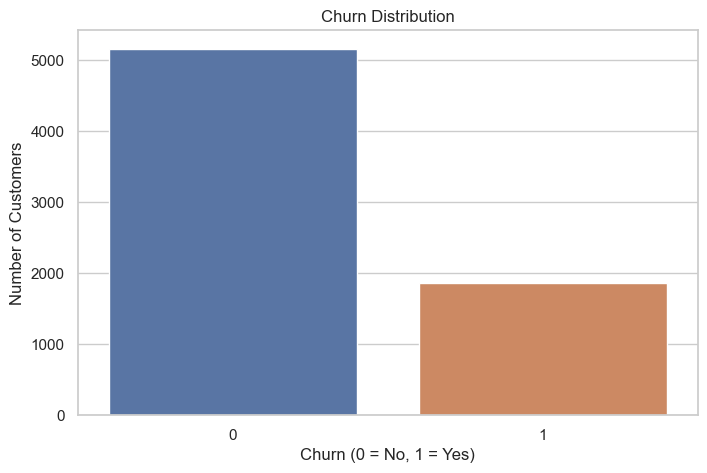

Overall churn rate: 26.45%


In [12]:
# ============================================================
# 5. Target Distribution
# ============================================================

sns.countplot(data=df_fe, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

churn_rate = df_fe["Churn"].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

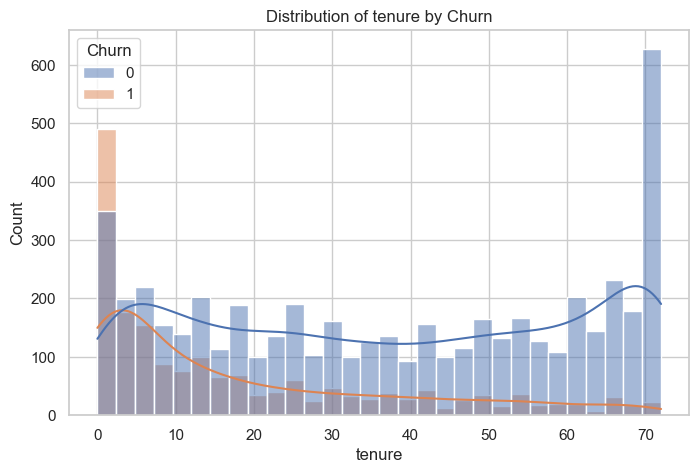

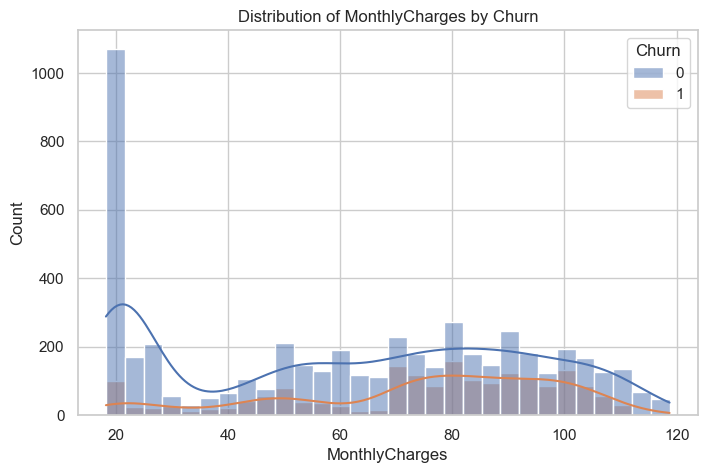

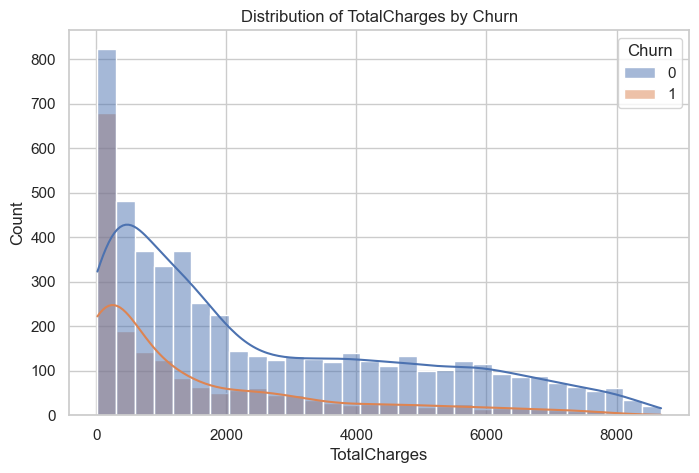

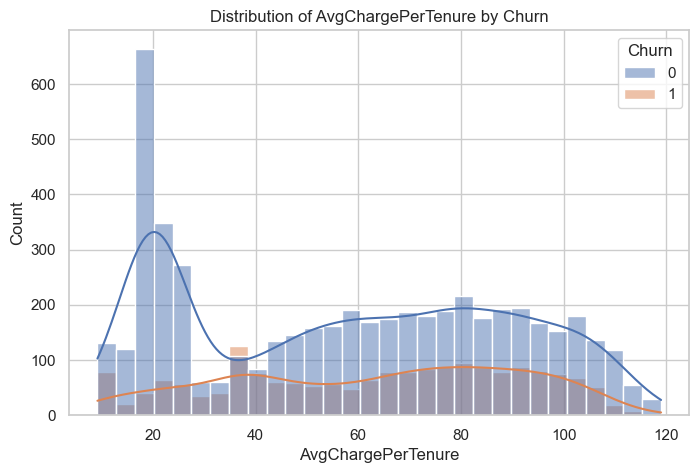

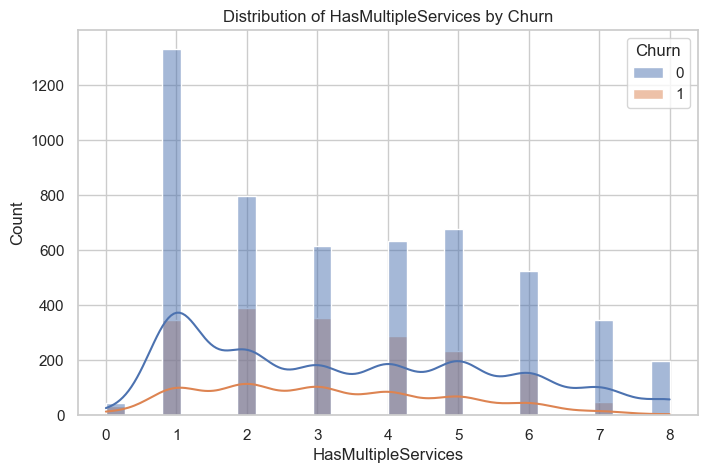

In [13]:
# ============================================================
# 6. Numeric Variable Distributions
# ============================================================

numeric_cols_for_plot = ["tenure", "MonthlyCharges", "TotalCharges", "AvgChargePerTenure", "HasMultipleServices"]

for col in numeric_cols_for_plot:
    plt.figure()
    sns.histplot(data=df_fe, x=col, hue="Churn", kde=True, bins=30)
    plt.title(f"Distribution of {col} by Churn")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

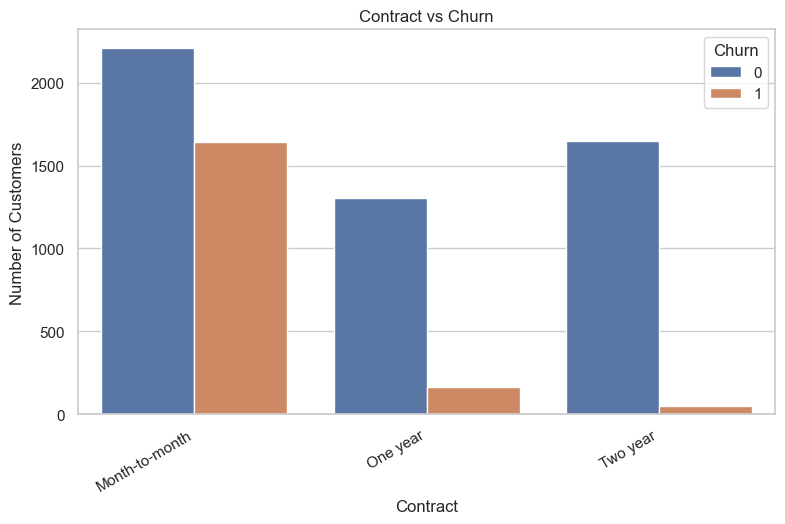

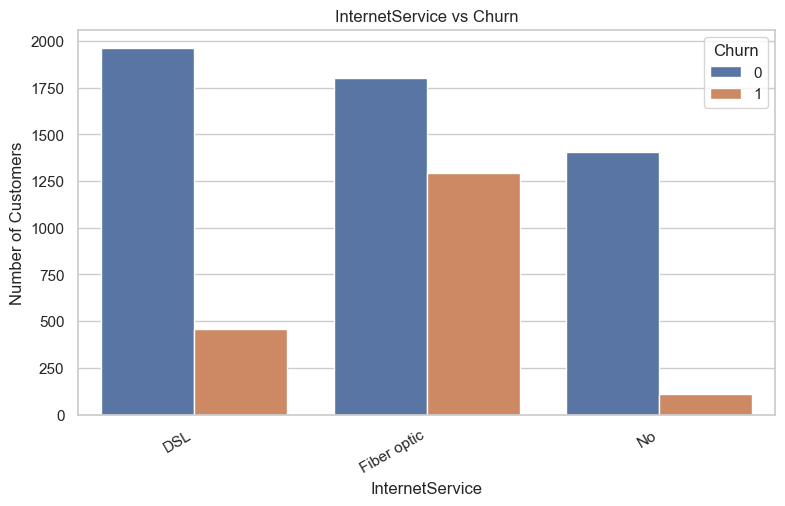

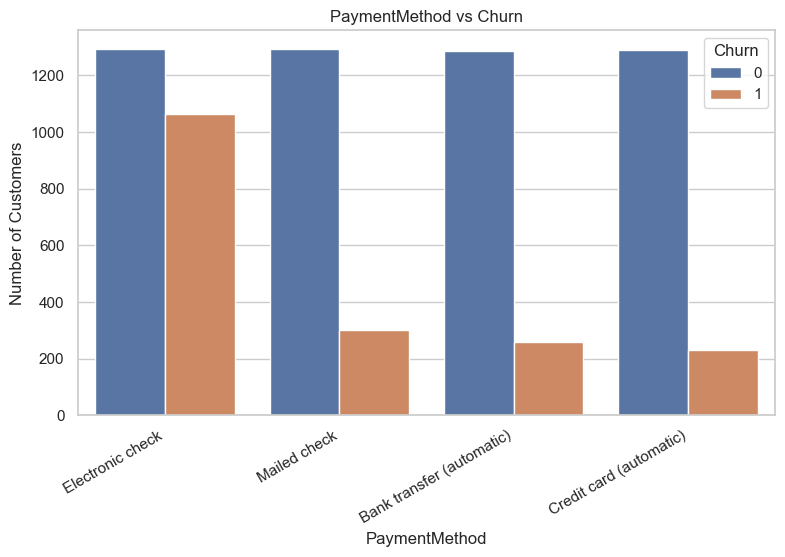

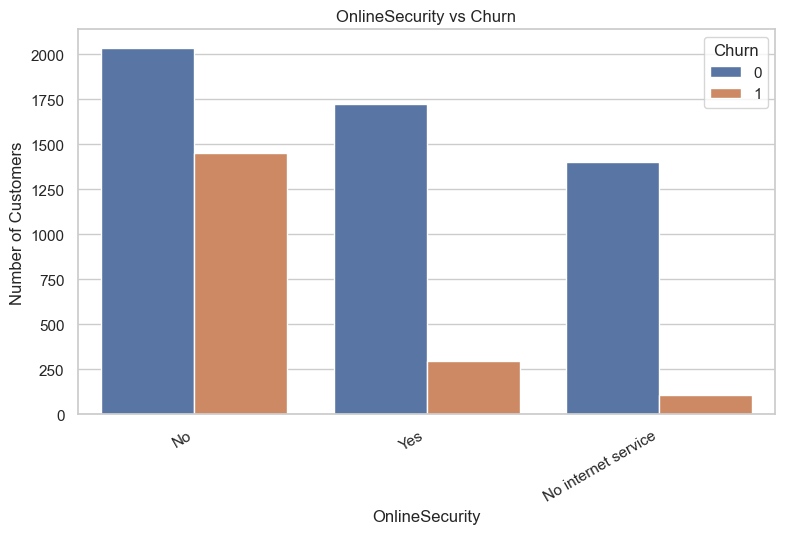

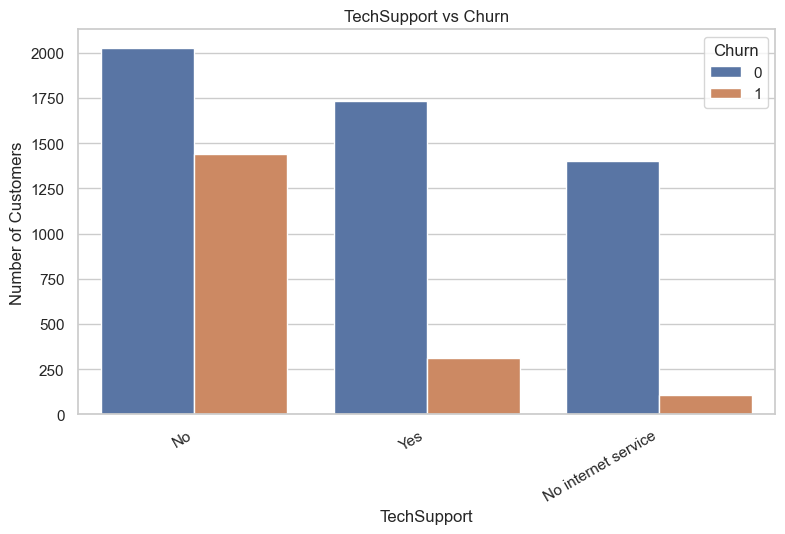

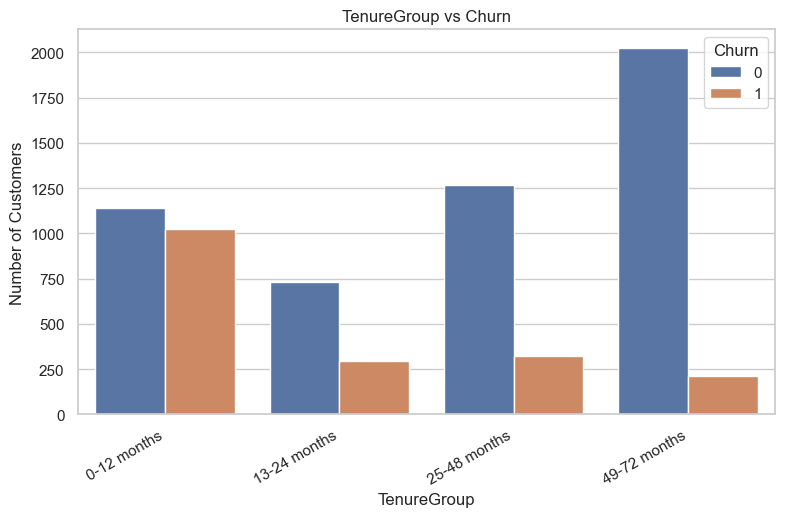

In [14]:
# ============================================================
# 7. Categorical Variable Visualizations
# ============================================================

categorical_cols_for_plot = ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport", "TenureGroup"]

for col in categorical_cols_for_plot:
    plt.figure(figsize=(9, 5))
    sns.countplot(data=df_fe, x=col, hue="Churn")
    plt.title(f"{col} vs Churn")
    plt.xlabel(col)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=30, ha="right")
    plt.show()

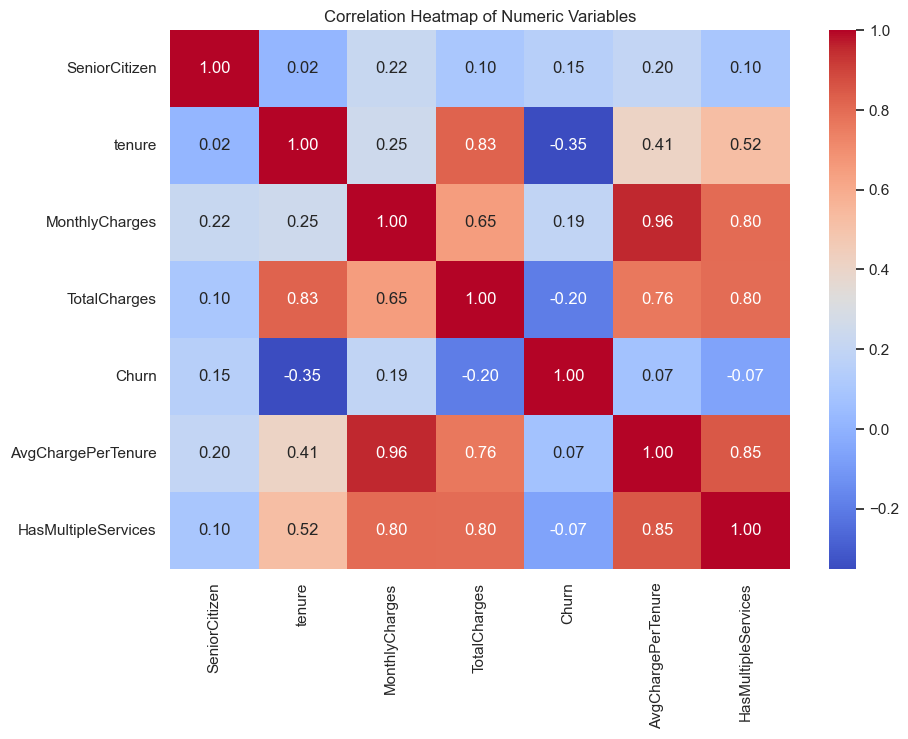

In [15]:
# ============================================================
# 8. Correlation Heatmap for Numeric Variables
# ============================================================

numeric_df = df_fe.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

## 7. Outlier Review

Outliers are checked using boxplots. In this dataset, very high charges or long tenure values are not necessarily errors because customers can naturally have different billing histories. Therefore, the project keeps these values unless they are impossible.

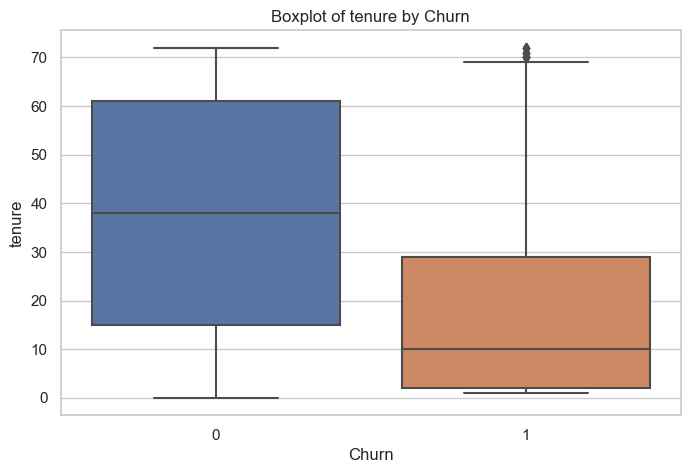

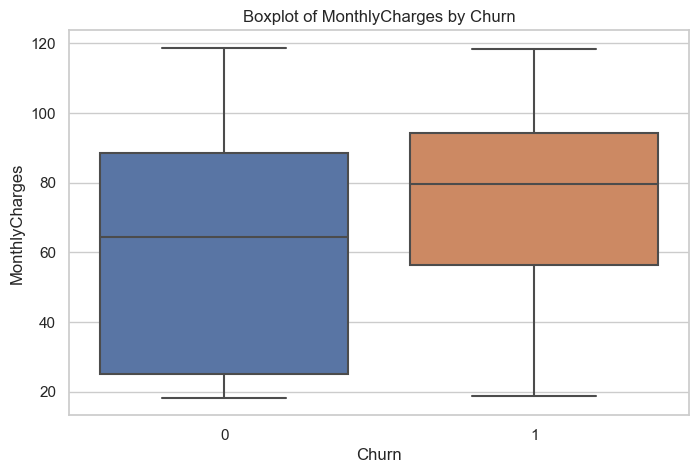

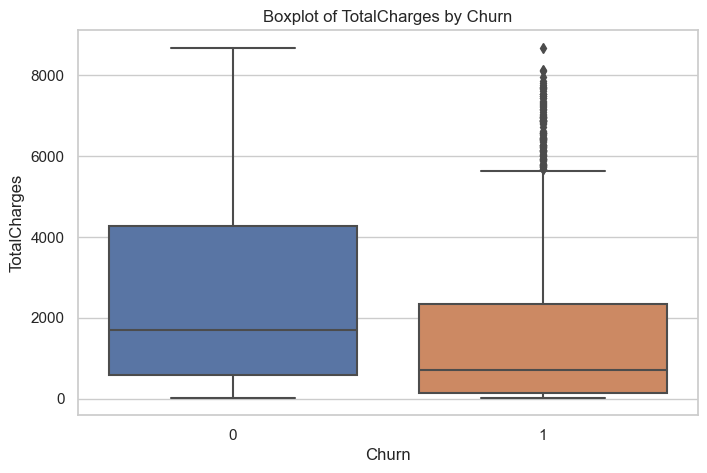

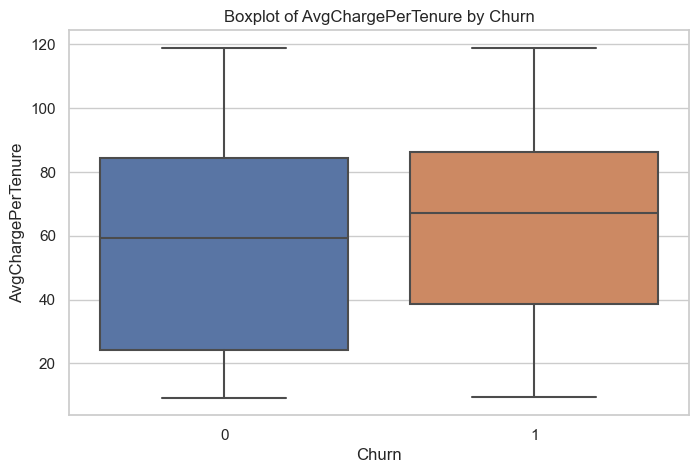

In [39]:
# ============================================================
# 9. Outlier Review
# ============================================================

for col in ["tenure", "MonthlyCharges", "TotalCharges", "AvgChargePerTenure"]:
    plt.figure()
    sns.boxplot(data=df_fe, x="Churn", y=col)
    plt.title(f"Boxplot of {col} by Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

## 8. Prepare Features and Target

The target variable is `Churn`. All other variables are used as predictors. Numeric variables will be imputed and scaled. Categorical variables will be imputed and one-hot encoded.

This follows a clean machine learning pipeline so the same preprocessing is applied correctly to training and testing data.

In [17]:
# ============================================================
# 10. Define Features and Target
# ============================================================

X = df_fe.drop(columns=["Churn"])
y = df_fe["Churn"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgChargePerTenure', 'HasMultipleServices']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup', 'HasInternetService']


In [18]:
# ============================================================
# 11. Train/Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (5616, 23)
Testing set: (1405, 23)

Training target distribution:
Churn
0    0.735577
1    0.264423
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.735231
1    0.264769
Name: proportion, dtype: float64


In [19]:
# ============================================================
# 12. Preprocessing Pipelines
# ============================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 9. Helper Functions for Model Evaluation

These functions make model comparison easier. For classification, this project reports accuracy, precision, recall, F1 score, and ROC-AUC.

In [20]:
# ============================================================
# 13. Evaluation Helper Functions
# ============================================================

def evaluate_classifier(model_name, model, X_train, y_train, X_test, y_test):
    """Fit model and return train/test evaluation metrics."""
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Some classifiers have predict_proba, others may have decision_function
    if hasattr(model, "predict_proba"):
        train_score = model.predict_proba(X_train)[:, 1]
        test_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        train_score = model.decision_function(X_train)
        test_score = model.decision_function(X_test)
    else:
        train_score = train_pred
        test_score = test_pred

    results = {
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Test Precision": precision_score(y_test, test_pred),
        "Test Recall": recall_score(y_test, test_pred),
        "Test F1": f1_score(y_test, test_pred),
        "Train ROC-AUC": roc_auc_score(y_train, train_score),
        "Test ROC-AUC": roc_auc_score(y_test, test_score)
    }

    return results


def show_confusion_matrix(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(y_test, y_pred))


def cross_validate_model(model, X, y, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X, y, cv=skf, scoring="roc_auc")
    print("Cross-validation ROC-AUC scores:", scores)
    print("Mean ROC-AUC:", scores.mean())
    print("Standard deviation:", scores.std())

## 10. Baseline Models

The guidelines require at least four meaningfully different models. This section includes several baseline models learned in class. Later, four main models are improved using tuning or better settings.

In [21]:
# ============================================================
# 14. Baseline Models
# ============================================================

baseline_models = {
    "Logistic Regression Baseline": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),

    "KNN Baseline": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Naive Bayes Baseline": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GaussianNB())
    ]),

    "Decision Tree Baseline": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),

    "Random Forest Baseline": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE))
    ]),

    "Gradient Boosting Baseline": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
    ])
}

baseline_results = []

for name, model in baseline_models.items():
    result = evaluate_classifier(name, model, X_train, y_train, X_test, y_test)
    baseline_results.append(result)

baseline_results_df = pd.DataFrame(baseline_results).sort_values(by="Test ROC-AUC", ascending=False)
baseline_results_df

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1,Train ROC-AUC,Test ROC-AUC
0,Logistic Regression Baseline,0.811788,0.807117,0.681004,0.510753,0.583717,0.853392,0.842107
5,Gradient Boosting Baseline,0.826567,0.800712,0.659722,0.510753,0.575758,0.882080,0.837267
4,Random Forest Baseline,0.997685,0.782206,0.624060,0.446237,0.520376,0.999985,0.818115
2,Naive Bayes Baseline,0.659900,0.646975,0.419689,0.870968,0.566434,0.822342,0.809094
1,KNN Baseline,0.836895,0.749466,0.530120,0.473118,0.500000,0.899761,0.759186
3,Decision Tree Baseline,0.997685,0.725267,0.482323,0.513441,0.497396,0.999986,0.658337


## 11. Improved Models

The final project asks for a clear development path from baseline to improved versions. The following models are improved using class weighting, regularization, tree depth control, number of estimators, learning rate, and grid search.

In [22]:
# ============================================================
# 15. Improved Model 1: Logistic Regression with Class Weight
# ============================================================

logreg_improved = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        C=0.5,
        random_state=RANDOM_STATE
    ))
])

logreg_result = evaluate_classifier(
    "Improved Logistic Regression",
    logreg_improved,
    X_train, y_train,
    X_test, y_test
)

pd.DataFrame([logreg_result])

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1,Train ROC-AUC,Test ROC-AUC
0,Improved Logistic Regression,0.758547,0.740925,0.507168,0.760753,0.608602,0.853277,0.841722


In [23]:
# ============================================================
# 16. Improved Model 2: Decision Tree with Grid Search
# ============================================================

dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

dt_param_grid = {
    "model__max_depth": [3, 4, 5, 6, 8, 10],
    "model__min_samples_split": [10, 20, 50],
    "model__min_samples_leaf": [5, 10, 20],
    "model__criterion": ["gini", "entropy"]
}

dt_grid = GridSearchCV(
    dt_pipeline,
    param_grid=dt_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree parameters:")
print(dt_grid.best_params_)

dt_result = evaluate_classifier(
    "Improved Decision Tree",
    dt_grid.best_estimator_,
    X_train, y_train,
    X_test, y_test
)

pd.DataFrame([dt_result])

Best Decision Tree parameters:
{'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_leaf': 20, 'model__min_samples_split': 10}


,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1,Train ROC-AUC,Test ROC-AUC
0,Improved Decision Tree,0.794872,0.7879,0.627586,0.489247,0.549849,0.846602,0.8258


In [24]:
# ============================================================
# 17. Improved Model 3: Random Forest with Tuned Parameters
# ============================================================

rf_improved = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_result = evaluate_classifier(
    "Improved Random Forest",
    rf_improved,
    X_train, y_train,
    X_test, y_test
)

pd.DataFrame([rf_result])

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1,Train ROC-AUC,Test ROC-AUC
0,Improved Random Forest,0.813212,0.768683,0.546351,0.744624,0.630262,0.90779,0.840915


In [25]:
# ============================================================
# 18. Improved Model 4: Gradient Boosting
# ============================================================

gb_improved = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ))
])

gb_result = evaluate_classifier(
    "Improved Gradient Boosting",
    gb_improved,
    X_train, y_train,
    X_test, y_test
)

pd.DataFrame([gb_result])

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1,Train ROC-AUC,Test ROC-AUC
0,Improved Gradient Boosting,0.827635,0.796441,0.651408,0.497312,0.564024,0.882866,0.836478


In [26]:
# ============================================================
# 19. Optional Advanced Boosting: HistGradientBoosting
# ============================================================

hgb_improved = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    ))
])

hgb_result = evaluate_classifier(
    "Hist Gradient Boosting",
    hgb_improved,
    X_train, y_train,
    X_test, y_test
)

pd.DataFrame([hgb_result])

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1,Train ROC-AUC,Test ROC-AUC
0,Hist Gradient Boosting,0.888711,0.791459,0.631229,0.510753,0.564636,0.956307,0.838935


## 12. Additional Models Learned in Class

This section includes extra models from class. These are useful for comparison, but the main final model comparison will focus on the stronger models.

In [27]:
# ============================================================
# 20. Extra Models from Class: LDA, QDA, KNN, Neural Network
# ============================================================

extra_models = {
    "LDA": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearDiscriminantAnalysis())
    ]),

    "QDA": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", QuadraticDiscriminantAnalysis())
    ]),

    "KNN Improved": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=15))
    ]),

    "Simple Neural Network": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", MLPClassifier(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            max_iter=500,
            random_state=RANDOM_STATE
        ))
    ])
}

extra_results = []

for name, model in extra_models.items():
    result = evaluate_classifier(name, model, X_train, y_train, X_test, y_test)
    extra_results.append(result)

extra_results_df = pd.DataFrame(extra_results).sort_values(by="Test ROC-AUC", ascending=False)
extra_results_df

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1,Train ROC-AUC,Test ROC-AUC
0,LDA,0.807336,0.807117,0.679715,0.513441,0.584992,0.848834,0.838370
1,QDA,0.780449,0.772954,0.559819,0.666667,0.608589,0.840581,0.827479
3,Simple Neural Network,0.844195,0.788612,0.636364,0.470430,0.540958,0.901905,0.825486
2,KNN Improved,0.814637,0.779359,0.598726,0.505376,0.548105,0.867862,0.815413


## 13. PCA and Clustering Exploration

These unsupervised learning techniques were covered in class. They are not used as the main prediction method here because churn has a clear target variable. However, PCA and K-Means can still help explore whether customers form natural groups.

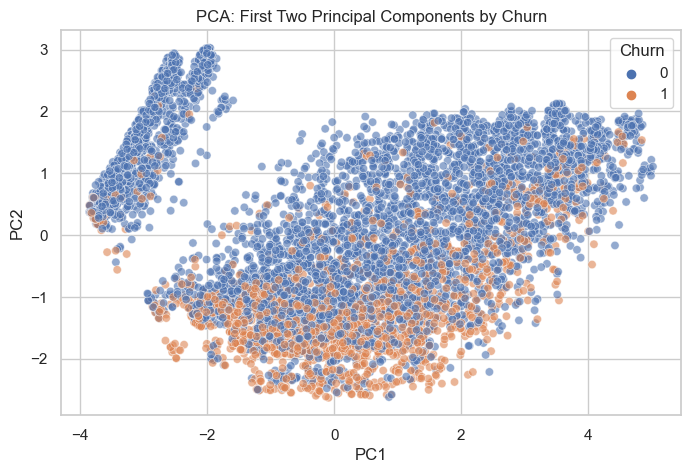

Explained variance ratio: [0.43448102 0.15038538]
Total explained variance: 0.5848664009895458


In [28]:
# ============================================================
# 21. PCA Exploration
# ============================================================

# Preprocess X into a numeric matrix
X_processed = preprocessor.fit_transform(X)

# Convert sparse matrix to dense if necessary
if hasattr(X_processed, "toarray"):
    X_processed_dense = X_processed.toarray()
else:
    X_processed_dense = X_processed

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_processed_dense)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Churn": y.values
})

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Churn", alpha=0.6)
plt.title("PCA: First Two Principal Components by Churn")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

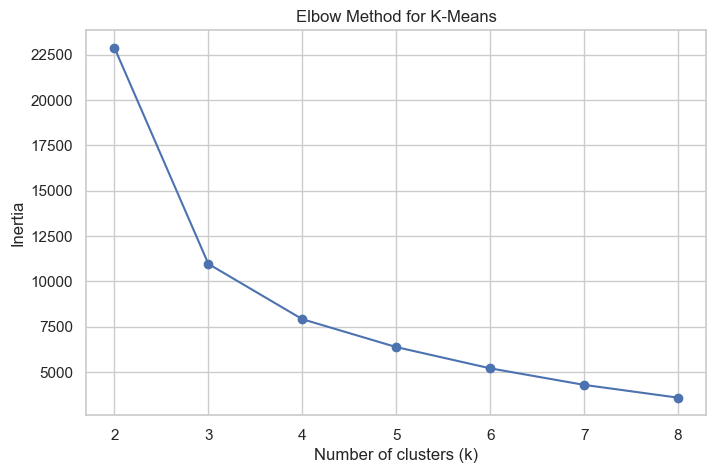

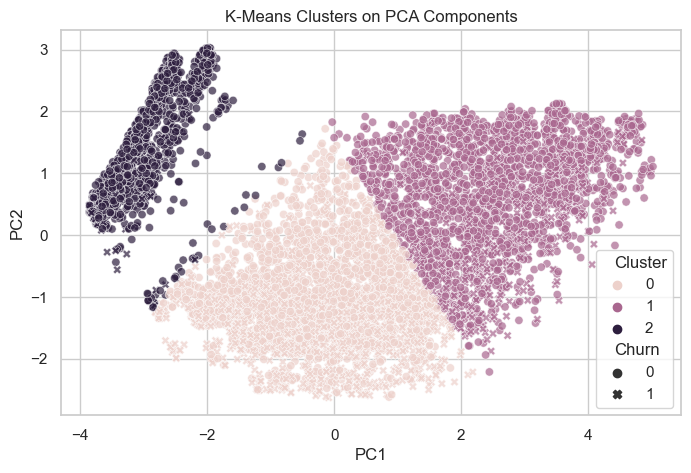

Churn,0,1
Cluster,,
0,0.569396,0.430604
1,0.836229,0.163771
2,0.924165,0.075835


In [29]:
# ============================================================
# 22. K-Means Clustering Exploration
# ============================================================

inertias = []
k_values = range(2, 9)

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

kmeans = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
pca_df["Cluster"] = kmeans.fit_predict(X_pca)

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", style="Churn", alpha=0.7)
plt.title("K-Means Clusters on PCA Components")
plt.show()

pd.crosstab(pca_df["Cluster"], pca_df["Churn"], normalize="index")

## 14. Cross-Validation for the Best Candidate Models

Cross-validation gives a more stable estimate of model performance because it evaluates the model across multiple training and validation splits.

In [30]:
# ============================================================
# 23. Cross-Validation of Improved Models
# ============================================================

cv_models = {
    "Improved Logistic Regression": logreg_improved,
    "Improved Decision Tree": dt_grid.best_estimator_,
    "Improved Random Forest": rf_improved,
    "Improved Gradient Boosting": gb_improved,
    "Hist Gradient Boosting": hgb_improved
}

cv_summary = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in cv_models.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring="roc_auc", n_jobs=-1)
    cv_summary.append({
        "Model": name,
        "Mean CV ROC-AUC": scores.mean(),
        "Std CV ROC-AUC": scores.std()
    })

cv_summary_df = pd.DataFrame(cv_summary).sort_values(by="Mean CV ROC-AUC", ascending=False)
cv_summary_df

,Model,Mean CV ROC-AUC,Std CV ROC-AUC
0,Improved Logistic Regression,0.848175,0.008538
3,Improved Gradient Boosting,0.847152,0.009470
2,Improved Random Forest,0.845655,0.010164
4,Hist Gradient Boosting,0.837280,0.005871
1,Improved Decision Tree,0.829896,0.005364


## 15. Final Model Comparison

This table combines baseline models, improved models, and extra models. The final recommendation should be based mainly on test ROC-AUC, F1 score, recall, and whether the model is overfitting.

In [31]:
# ============================================================
# 24. Final Model Comparison Table
# ============================================================

improved_results_df = pd.DataFrame([
    logreg_result,
    dt_result,
    rf_result,
    gb_result,
    hgb_result
])

all_results_df = pd.concat(
    [baseline_results_df, improved_results_df, extra_results_df],
    ignore_index=True
).sort_values(by="Test ROC-AUC", ascending=False)

all_results_df

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1,Train ROC-AUC,Test ROC-AUC
0,Logistic Regression Baseline,0.811788,0.807117,0.681004,0.510753,0.583717,0.853392,0.842107
6,Improved Logistic Regression,0.758547,0.740925,0.507168,0.760753,0.608602,0.853277,0.841722
8,Improved Random Forest,0.813212,0.768683,0.546351,0.744624,0.630262,0.907790,0.840915
10,Hist Gradient Boosting,0.888711,0.791459,0.631229,0.510753,0.564636,0.956307,0.838935
11,LDA,0.807336,0.807117,0.679715,0.513441,0.584992,0.848834,0.838370
1,Gradient Boosting Baseline,0.826567,0.800712,0.659722,0.510753,0.575758,0.882080,0.837267
9,Improved Gradient Boosting,0.827635,0.796441,0.651408,0.497312,0.564024,0.882866,0.836478
12,QDA,0.780449,0.772954,0.559819,0.666667,0.608589,0.840581,0.827479
7,Improved Decision Tree,0.794872,0.787900,0.627586,0.489247,0.549849,0.846602,0.825800
13,Simple Neural Network,0.844195,0.788612,0.636364,0.470430,0.540958,0.901905,0.825486


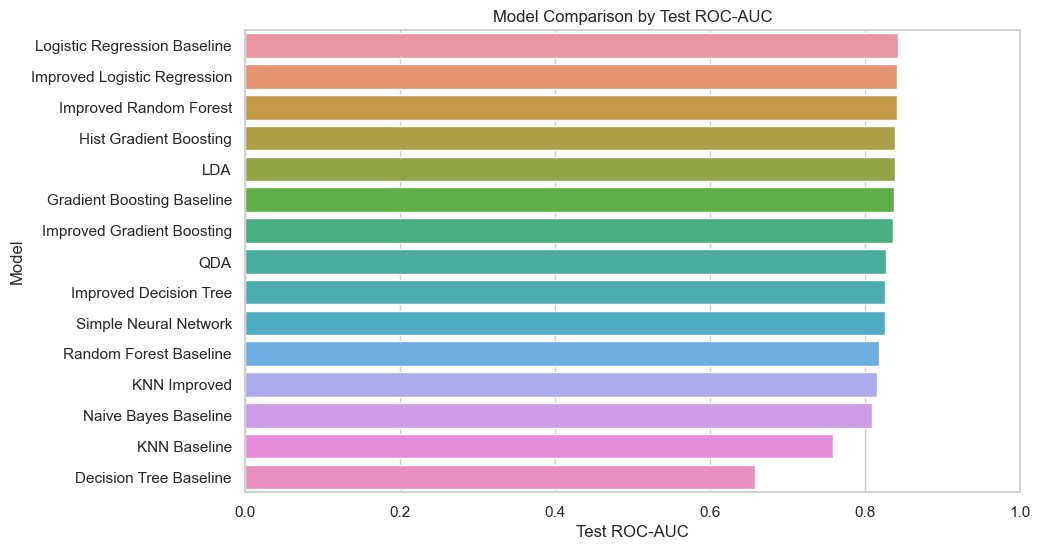

In [32]:
# Plot final model comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=all_results_df, y="Model", x="Test ROC-AUC")
plt.title("Model Comparison by Test ROC-AUC")
plt.xlabel("Test ROC-AUC")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.show()

In [33]:
# Baseline vs improved comparison for the four main model families
main_compare = all_results_df[
    all_results_df["Model"].isin([
        "Logistic Regression Baseline",
        "Improved Logistic Regression",
        "Decision Tree Baseline",
        "Improved Decision Tree",
        "Random Forest Baseline",
        "Improved Random Forest",
        "Gradient Boosting Baseline",
        "Improved Gradient Boosting"
    ])
].copy()

main_compare.sort_values("Model")

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1,Train ROC-AUC,Test ROC-AUC
5,Decision Tree Baseline,0.997685,0.725267,0.482323,0.513441,0.497396,0.999986,0.658337
1,Gradient Boosting Baseline,0.826567,0.800712,0.659722,0.510753,0.575758,0.882080,0.837267
7,Improved Decision Tree,0.794872,0.787900,0.627586,0.489247,0.549849,0.846602,0.825800
9,Improved Gradient Boosting,0.827635,0.796441,0.651408,0.497312,0.564024,0.882866,0.836478
6,Improved Logistic Regression,0.758547,0.740925,0.507168,0.760753,0.608602,0.853277,0.841722
8,Improved Random Forest,0.813212,0.768683,0.546351,0.744624,0.630262,0.907790,0.840915
0,Logistic Regression Baseline,0.811788,0.807117,0.681004,0.510753,0.583717,0.853392,0.842107
2,Random Forest Baseline,0.997685,0.782206,0.624060,0.446237,0.520376,0.999985,0.818115


## 16. Confusion Matrix and ROC Curve for the Best Model

The best model is selected using test ROC-AUC by default. After selecting the best model, this section shows the confusion matrix, classification report, and ROC curve.

Best model based on Test ROC-AUC: Logistic Regression Baseline


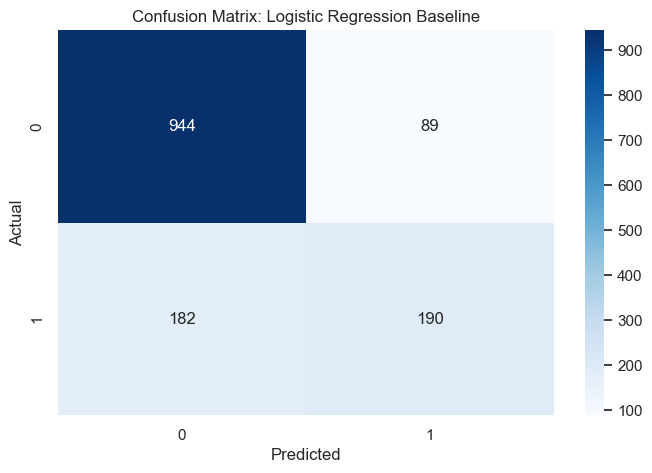

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1033
           1       0.68      0.51      0.58       372

    accuracy                           0.81      1405
   macro avg       0.76      0.71      0.73      1405
weighted avg       0.80      0.81      0.80      1405



In [34]:
# ============================================================
# 25. Select Best Model by Test ROC-AUC
# ============================================================

best_model_name = all_results_df.iloc[0]["Model"]
print("Best model based on Test ROC-AUC:", best_model_name)

model_lookup = {}
model_lookup.update(baseline_models)
model_lookup.update(cv_models)
model_lookup.update(extra_models)

best_model = model_lookup[best_model_name]
best_model.fit(X_train, y_train)

show_confusion_matrix(best_model, X_test, y_test, f"Confusion Matrix: {best_model_name}")

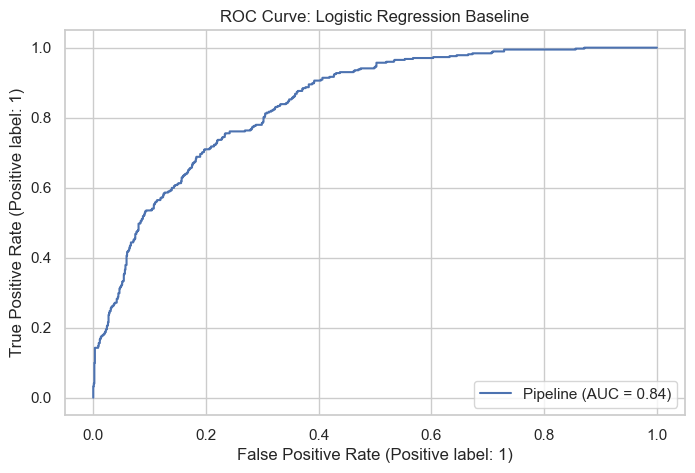

In [35]:
# ROC Curve for the best model
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f"ROC Curve: {best_model_name}")
plt.show()

## 17. Learning Curve: Bias vs. Variance

Learning curves help diagnose whether a model is overfitting or underfitting. If training performance is much higher than validation performance, the model may be overfitting. If both are low, the model may be underfitting.

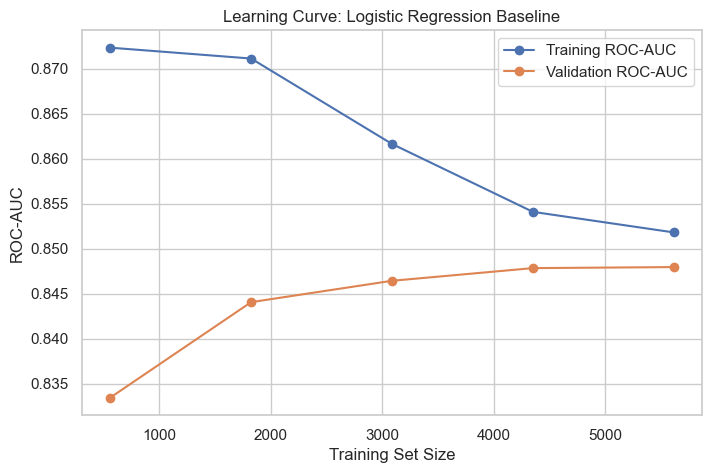

In [36]:
# ============================================================
# 26. Learning Curve for Best Model
# ============================================================

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, marker="o", label="Training ROC-AUC")
plt.plot(train_sizes, val_mean, marker="o", label="Validation ROC-AUC")
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title(f"Learning Curve: {best_model_name}")
plt.legend()
plt.show()

## 18. Feature Importance / Model Interpretation

For tree-based models, feature importance can show which variables are most influential. For logistic regression, coefficients can show the direction of influence. This helps connect the model results back to business understanding.

In [37]:
# ============================================================
# 27. Feature Names After Encoding
# ============================================================

# Fit preprocessor to get feature names
preprocessor.fit(X_train)

try:
    encoded_cat_names = preprocessor.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features)
    final_feature_names = numeric_features + list(encoded_cat_names)
    print("Number of final features:", len(final_feature_names))
except Exception as e:
    print("Could not extract feature names:", e)
    final_feature_names = None

Number of final features: 36


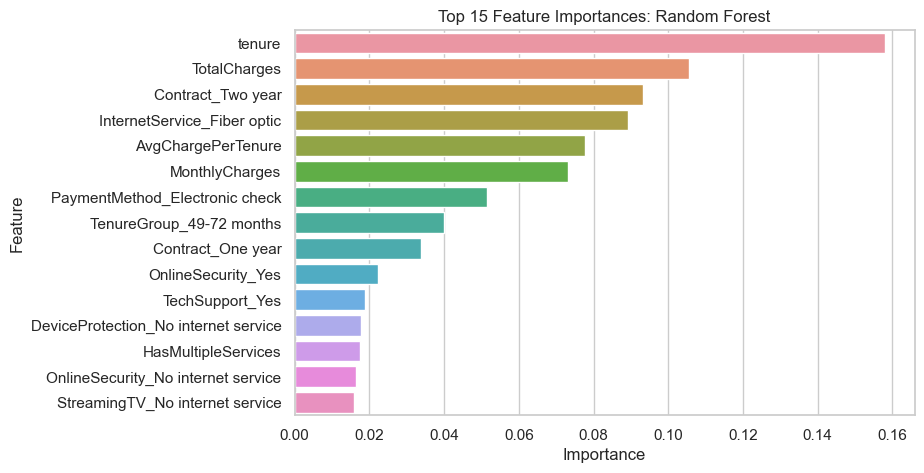

In [38]:
# ============================================================
# 28. Feature Importance for Random Forest
# ============================================================

rf_improved.fit(X_train, y_train)

rf_model = rf_improved.named_steps["model"]

if final_feature_names is not None and hasattr(rf_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": final_feature_names,
        "Importance": rf_model.feature_importances_
    }).sort_values(by="Importance", ascending=False).head(15)

    sns.barplot(data=importance_df, x="Importance", y="Feature")
    plt.title("Top 15 Feature Importances: Random Forest")
    plt.show()

    importance_df
else:
    print("Feature importance is not available.")


# 19. Findings and Model Comparison

The objective of this project was to predict customer churn in a telecommunications company using machine learning techniques. Multiple baseline, improved, and advanced classification models were developed and evaluated using metrics such as Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

The best-performing model in this analysis was the Logistic Regression Baseline model based on Test ROC-AUC, achieving a Test ROC-AUC score of approximately 0.842. The model also achieved a Test Accuracy of about 80.7% and demonstrated stable performance between training and testing datasets, indicating good generalization and limited overfitting.

The analysis revealed several important churn patterns. Customers with month-to-month contracts showed significantly higher churn rates compared to customers with one-year or two-year contracts. Customers with fiber optic internet service also experienced higher churn levels than DSL customers. In addition, customers without online security or tech support services were more likely to leave the company.

Customer tenure was another major factor influencing churn behavior. Customers with shorter tenure periods had much higher churn rates, while long-term customers were more likely to remain with the company. Higher monthly charges were also associated with increased churn probability.

Several improved models were tested, including tuned Decision Tree, Random Forest, Gradient Boosting, HistGradientBoosting, and balanced Logistic Regression models. Although some improved models increased recall and F1 score, none significantly outperformed the baseline Logistic Regression model in overall ROC-AUC performance.

The Random Forest and Decision Tree baseline models showed extremely high training scores but noticeably lower testing performance, suggesting overfitting. After parameter tuning, the improved versions demonstrated more balanced behavior and better generalization.

Cross-validation results also confirmed the consistency of the strongest models. Improved Logistic Regression achieved the highest mean cross-validation ROC-AUC score of approximately 0.848, followed closely by Gradient Boosting and Random Forest models.

The PCA and clustering analysis showed that customer groups with different churn behaviors naturally existed in the dataset. However, because churn prediction is a supervised learning problem, classification models remained more effective than unsupervised clustering techniques.

---

# 20. Conclusion

This project successfully applied machine learning techniques to predict customer churn in a telecommunications company. The analysis included data cleaning, feature engineering, exploratory data analysis, preprocessing pipelines, model development, hyperparameter tuning, cross-validation, and final model comparison.

Among all evaluated models, Logistic Regression provided the best balance between predictive performance, stability, and interpretability. The model achieved strong ROC-AUC performance while maintaining good generalization on unseen data.

The findings suggest that customer churn is strongly influenced by contract type, customer tenure, monthly charges, internet service type, and support-related services. Customers with short-term contracts, high monthly costs, and limited support services were more likely to churn. These insights can help telecommunications companies develop targeted retention strategies such as loyalty programs, personalized offers, long-term contract incentives, and improved customer support services.

This project also demonstrated the importance of proper preprocessing, feature engineering, and model evaluation in machine learning workflows. While more complex models such as Random Forest, Gradient Boosting, and Neural Networks performed competitively, simpler models like Logistic Regression were still highly effective for this structured business dataset.

Future improvements could include using larger datasets, incorporating external behavioral variables, handling class imbalance using advanced sampling techniques, and exploring deep learning approaches for improved churn prediction performance.